RNN and MLP Performance Analysis Based on Number of Trajectories

Results observation: The RNN benefitted significantly more from increasing the number of training trajectories than the MLP did. This suggests that the RNN was able to obtain a more complete picture of the gridworld and thus be more aware of its position.

In [107]:
import os
import sys

REMOTE_PROJECT = "/mnt/d/remote/Levenstein"

os.chdir(REMOTE_PROJECT)

if REMOTE_PROJECT not in sys.path:
    sys.path.insert(0, REMOTE_PROJECT)

print("Running from:", os.getcwd())
print(os.listdir())

Running from: /mnt/d/remote/Levenstein
['.gitgnore', '.venv', '.vscode', 'Experiments', 'functions', 'gridworld_experiment_SimpleMLP.py', 'loss.png', 'plot.png', 'Pytorch Tutorial', 'Sequential predictive learning is a unifying theory for hippocampal representation.pdf', '__pycache__']


In [108]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports

In [109]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
from IPython.display import display, Markdown
import functions.trajectories as trajectories
import functions.NN_models as NN_models
import functions.gridworld as gridworld
import functions.model_training_evaluator as model_training_evaluator
import functions.dataset_generator as dataset_generator
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/sebil/miniconda3/envs/main/bin/python
2.10.0+cu128


State variables

In [110]:

HEIGHT = 29
WIDTH = 36
VIEW_SIZE = 5

START_X = 7
START_Y = 7
START_DIRECTION = 2

N_STEPS = 500
N_TRAJ = 20

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]
ACTION_PROBS_TURN_HEAVY = [0.3, 0.35, 0.35, 0.0]

SEED = 42
TRAINER_MOVE_SEED = 100
TRAINER_START_SEED = 150
VALIDATOR_MOVE_SEED = 300
VALIDATOR_START_SEED = 350

TEST_SEED = 123
TEST_STEPS = 200

TRAINING_EPOCHS = 3000

Gridworld Creation

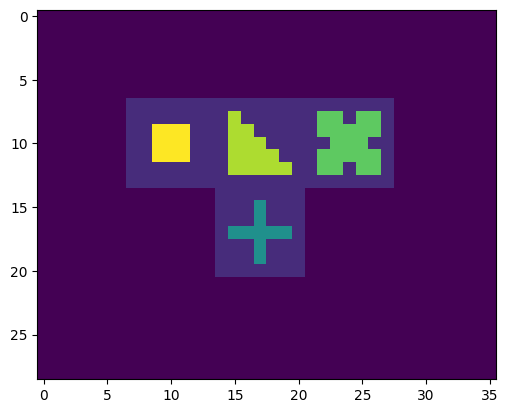

In [111]:
grid = gridworld.GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(7, 14, 7, 28)
grid.add_rectangle_region(14, 21, 14, 21)
grid.add_square_shape(9, 9, 3, 7)
grid.add_triangle_shape(8, 15, 5, 0, 6)
grid.add_square_shape(9, 23, 3, 5)
grid.add_square_shape(8, 22, 2, 5)
grid.add_square_shape(11, 22, 2, 5)
grid.add_square_shape(11, 25, 2, 5)
grid.add_square_shape(8, 25, 2, 5)
grid.add_rectangle_shape(15, 17, 5, 1, 3)
grid.add_rectangle_shape(17, 15, 1, 5, 3)
plt.imshow(grid.grid)


NN Training and Validation

RNN Trainer final loss: 0.7565118670463562
RNN Validator final loss: 0.9800595641136169


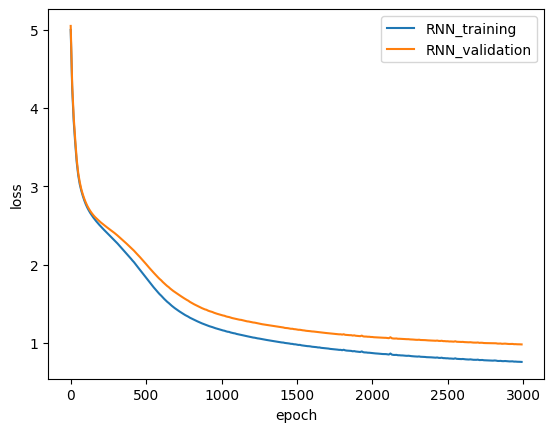

Baseline loss:  4.591728210449219
Baseline loss:  4.676159858703613


In [112]:


#Generate trainer and validator agents
trainer_inputs_stack, trainer_target_stack, trainer_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, N_TRAJ, TRAINER_MOVE_SEED, random_start=True, start_seed_start=TRAINER_START_SEED)
validator_inputs_stack, validator_target_stack, validator_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, 5, VALIDATOR_MOVE_SEED, random_start=True, start_seed_start=VALIDATOR_START_SEED)


INPUT_SIZE = trainer_inputs_stack.shape[2]
OUTPUT_SIZE = trainer_target_stack.shape[2]
HIDDEN_SIZE = 64     

#Train RNN

model_RNN = NN_models.BasicRNN(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
RNN_loss_info = model_training_evaluator.model_training(model_RNN, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack, TRAINING_EPOCHS)
print(f"RNN Trainer final loss: {RNN_loss_info[1][-1]}")
print(f"RNN Validator final loss: {RNN_loss_info[2][-1]}")

model_training_evaluator.plot_training_result(RNN_loss_info, "epoch", "loss", "RNN_training", "RNN_validation")

#Baseline Loss Evaluation

model_training_evaluator.baseline_evaluation(trainer_inputs_stack, trainer_target_stack)
model_training_evaluator.baseline_evaluation(validator_inputs_stack, validator_target_stack)



Validator Error per Action Type

In [113]:
results_array = []

trainer_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, trainer_inputs_stack, trainer_target_stack)
validator_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, validator_inputs_stack, validator_target_stack)

results_array.append(trainer_RNN_action_losses)
results_array.append(validator_RNN_action_losses)

results = pd.DataFrame(
    results_array,
    index = ["trainer, RNN", "validator, RNN"],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results

,Forward,Left,Right,Stop
"trainer, RNN",0.331498,1.521911,1.485596,1.045679
"validator, RNN",0.447920,1.959783,2.142335,1.246249


Spatial tuning analysis: Trajectory creation

In [128]:
stuning_inputs_stack, stuning_target_stack, stuning_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, 3000, 50, TRAINER_MOVE_SEED + 1, random_start=True, start_seed_start=(TRAINER_START_SEED-1))
all_hidden_states = model_RNN.get_hidden_states(stuning_inputs_stack)

all_positions_directions = []

for agents in stuning_agent_list:
    positions_directions = agents.states[1:]
    all_positions_directions.append(positions_directions)

all_positions_directions = torch.tensor(all_positions_directions)

hidden_flat = all_hidden_states.reshape(-1, 64)
states_flat = all_positions_directions.reshape(-1, 3)

xycoded_states_flat = []
for x, y, direction in states_flat:
    coded_coords = x * 100 + y
    xycoded_states_flat.append([coded_coords, direction])

position_hidden = {}
for i in range(len(xycoded_states_flat)):
    position = xycoded_states_flat[i][0].item()
    hidden = hidden_flat[i]

    if position not in position_hidden:
        position_hidden[position] = []

    position_hidden[position].append(hidden)



/tmp/ipykernel_957414/2364239484.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  agent_states = np.array(states_flat)


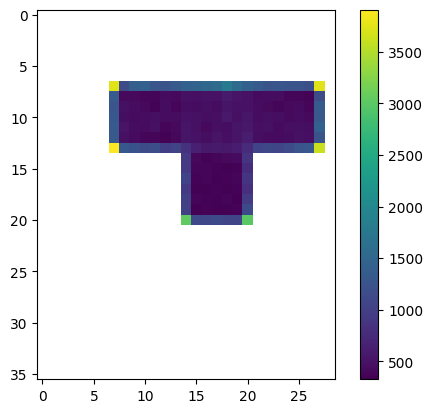

In [129]:
gridtest = np.full((WIDTH, HEIGHT), np.nan)
agent_states = np.array(states_flat)
for states in agent_states:
    if np.isnan(gridtest[states[0], states[1]]):
        gridtest[states[0], states[1]] = 1
    else:
        gridtest[states[0], states[1]] += 1

plt.imshow(gridtest)
plt.colorbar()

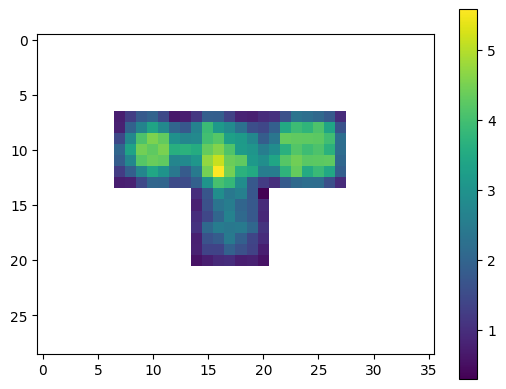

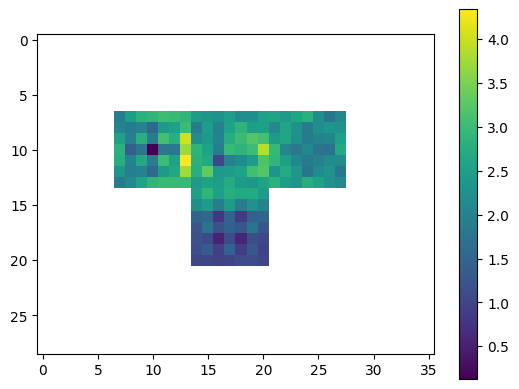

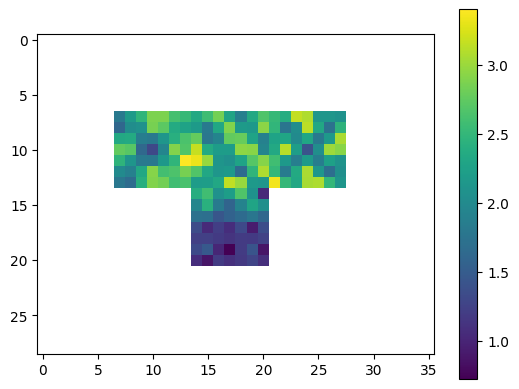

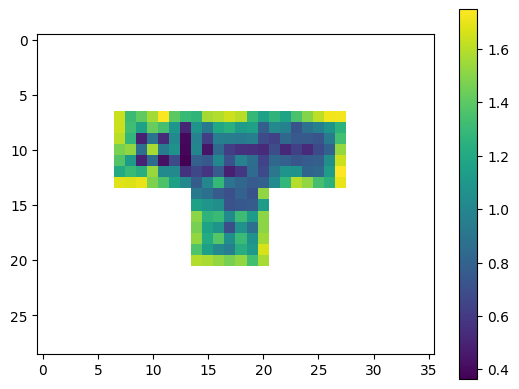

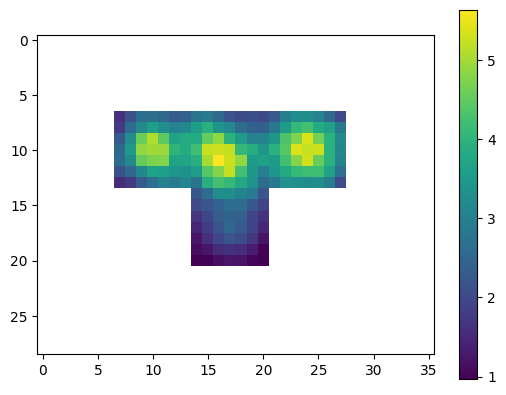

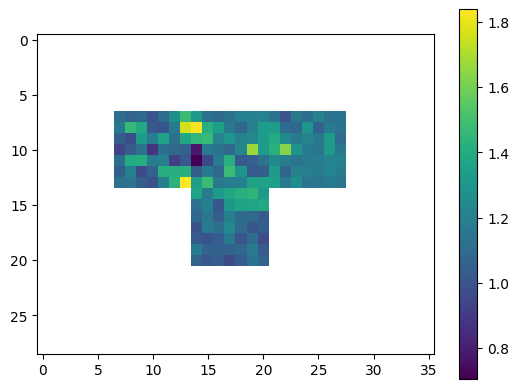

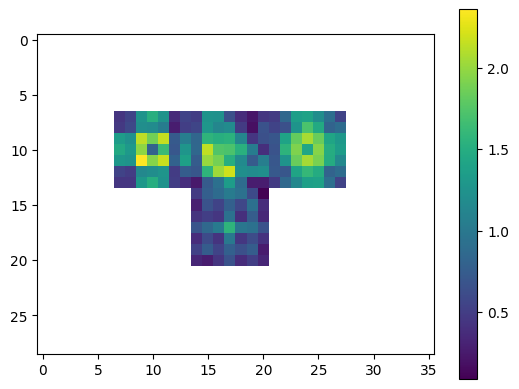

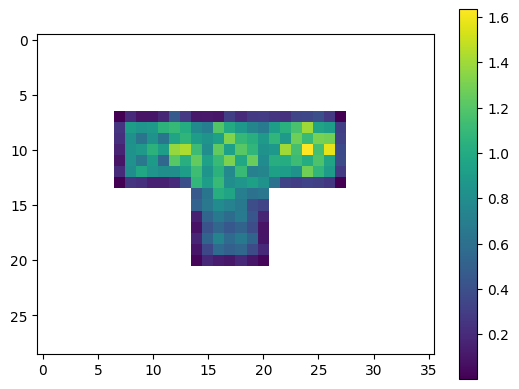

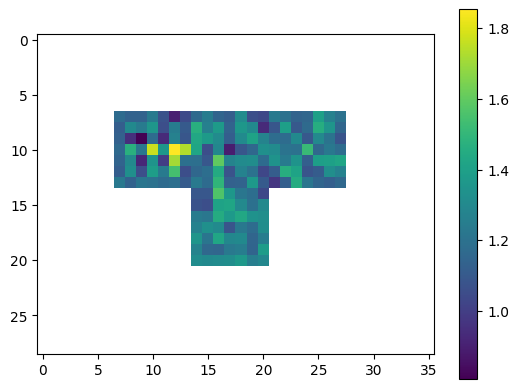

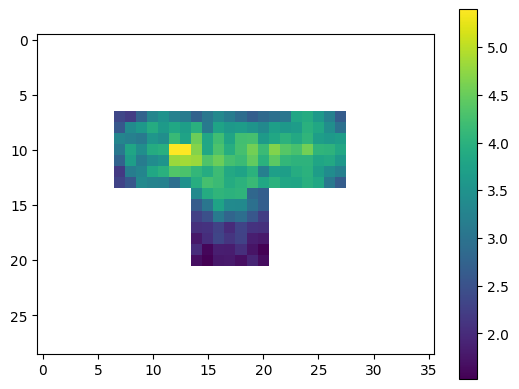

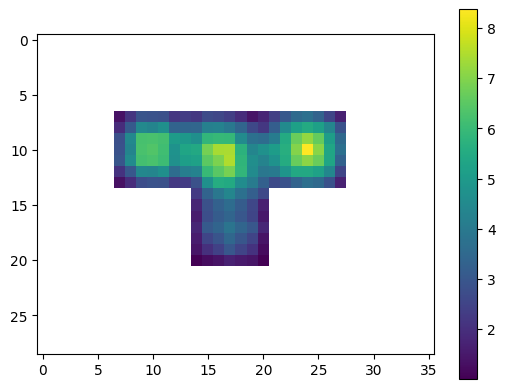

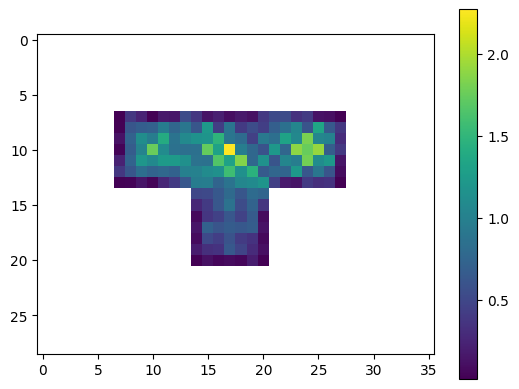

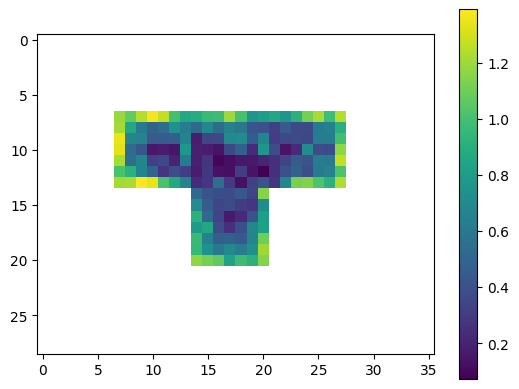

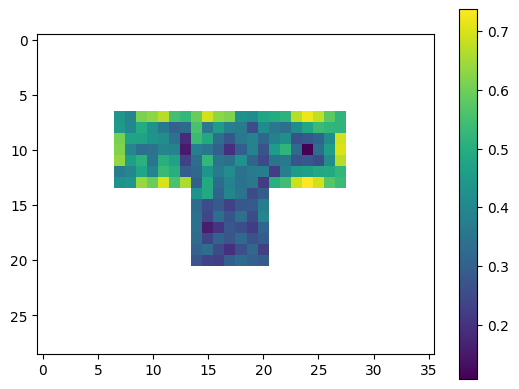

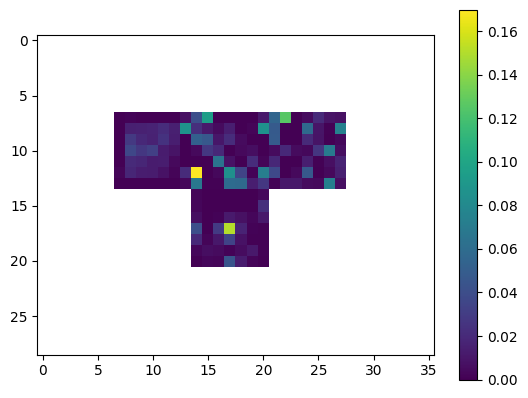

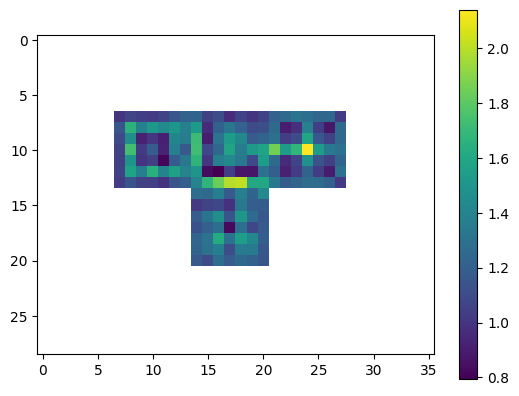

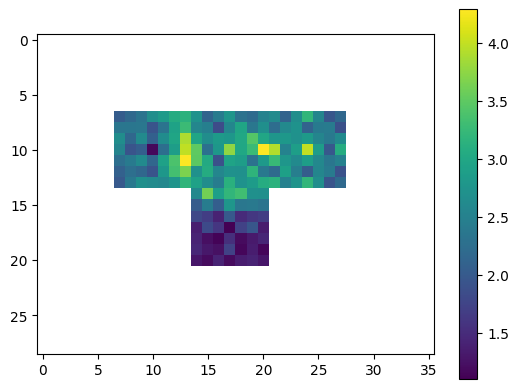

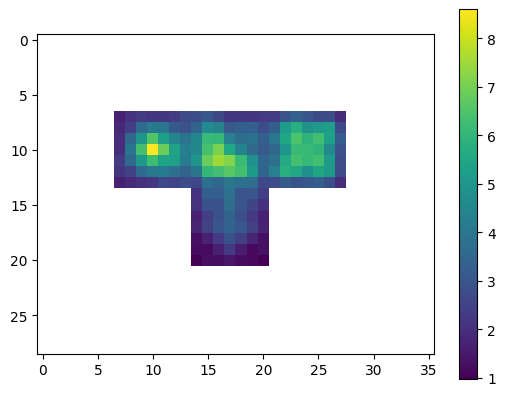

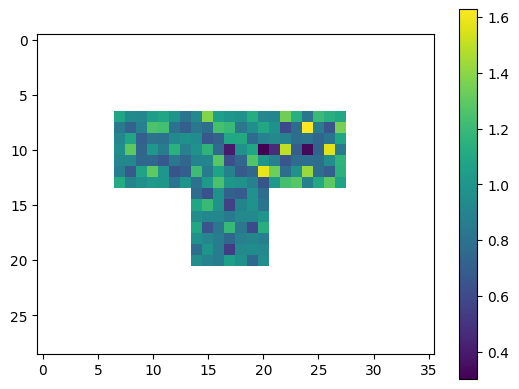

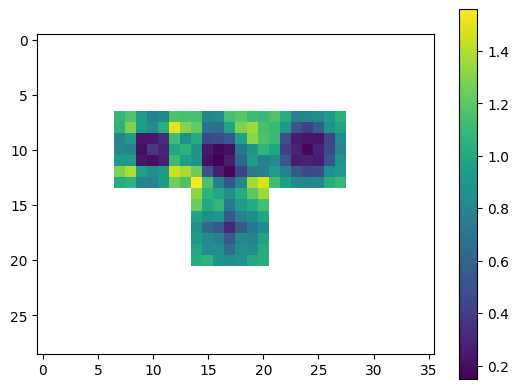

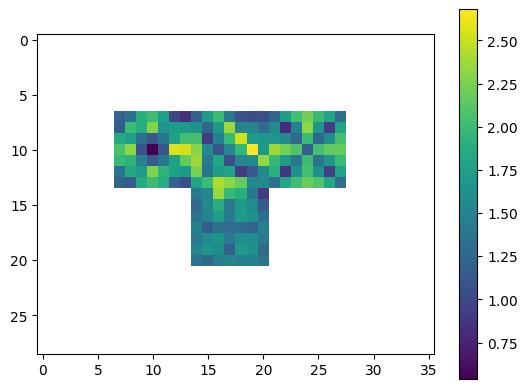

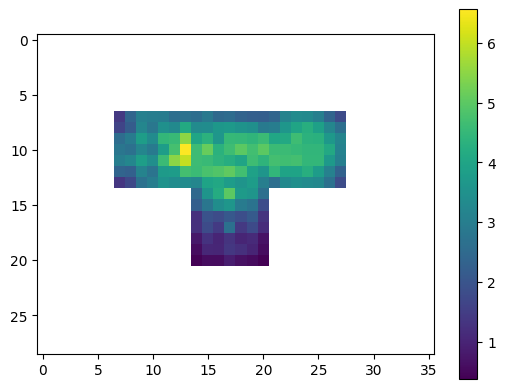

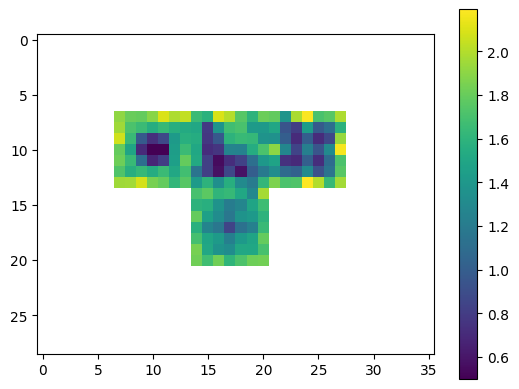

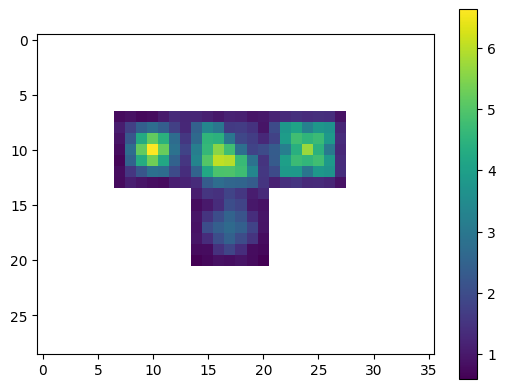

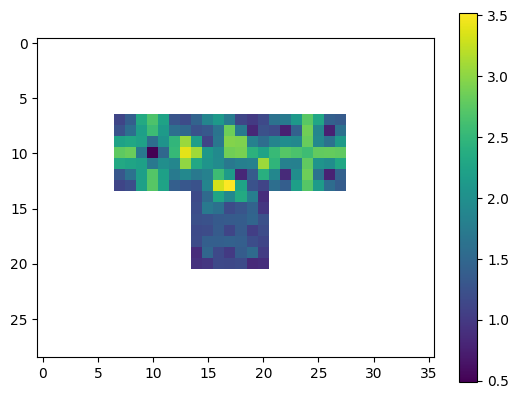

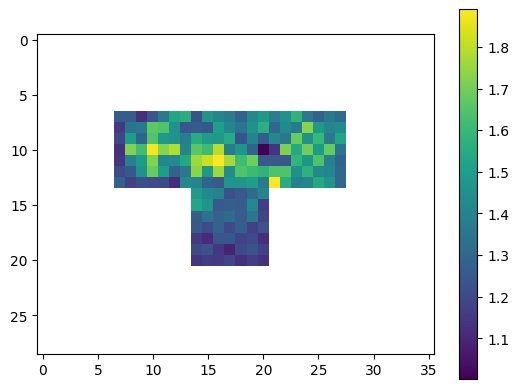

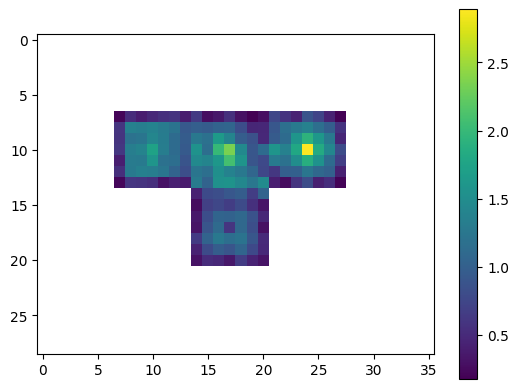

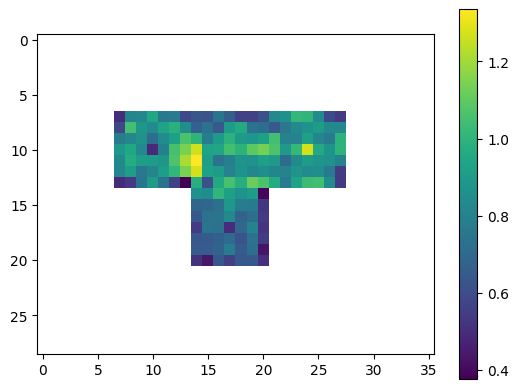

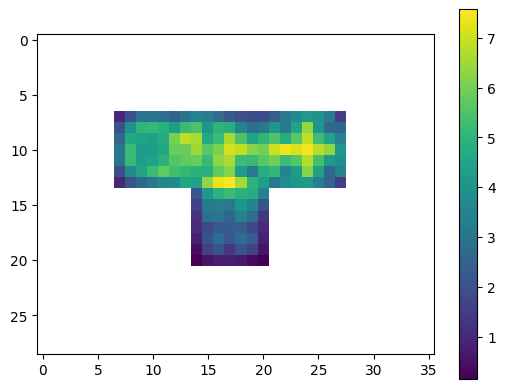

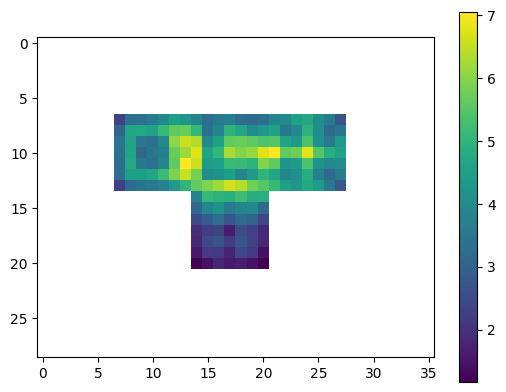

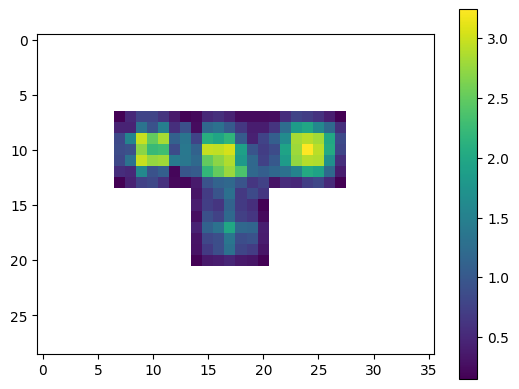

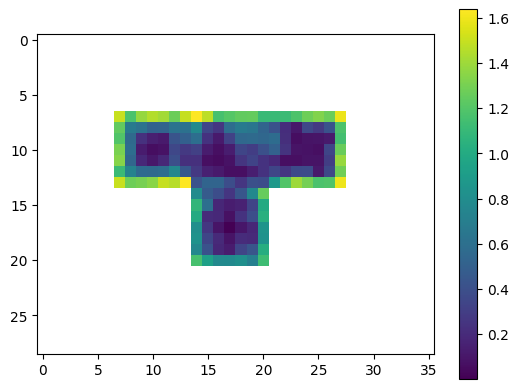

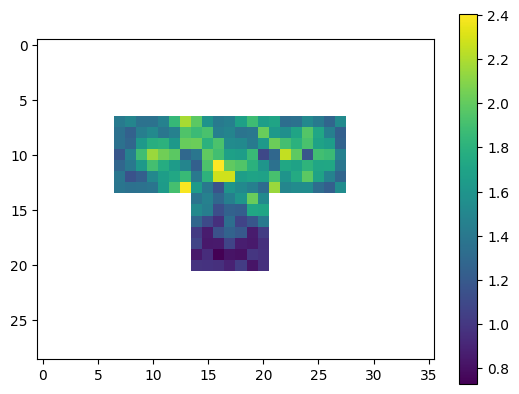

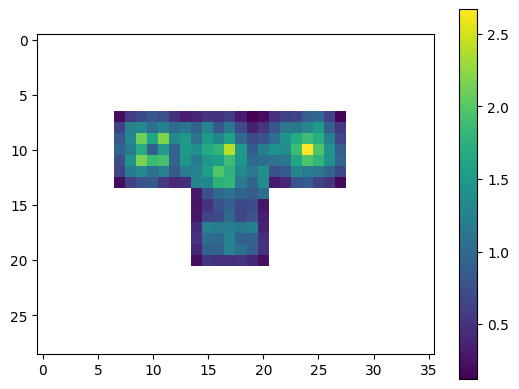

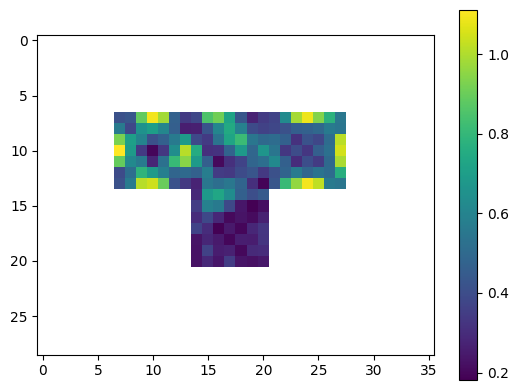

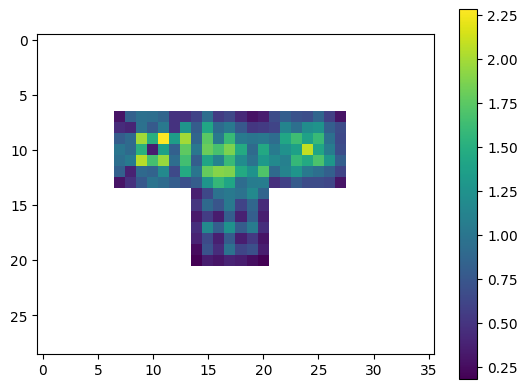

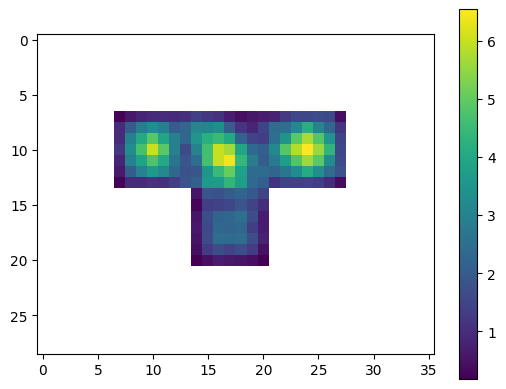

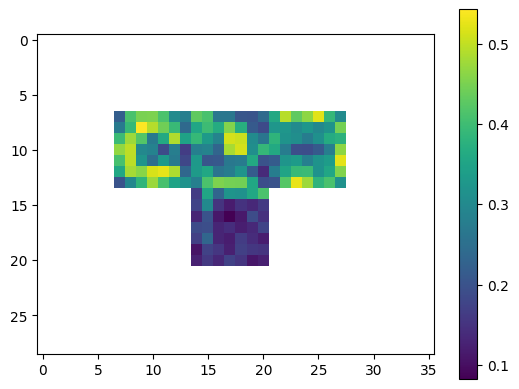

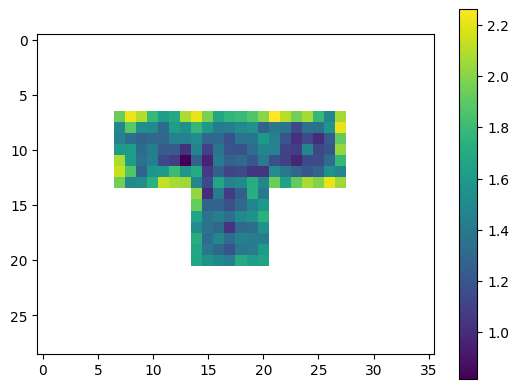

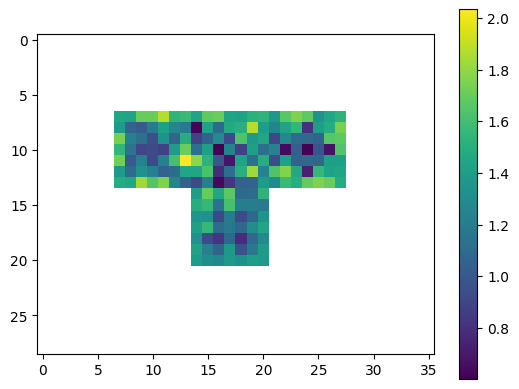

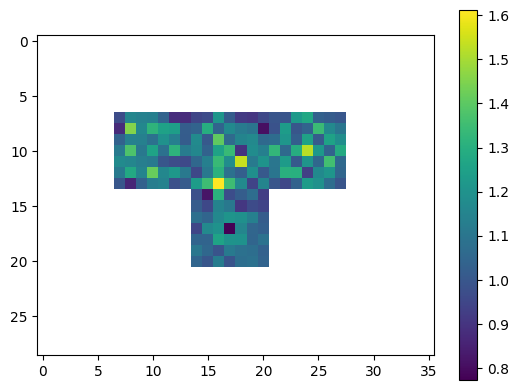

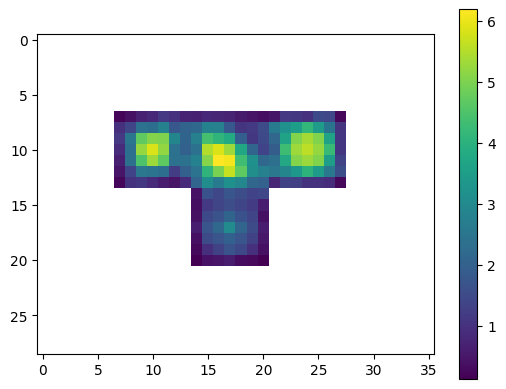

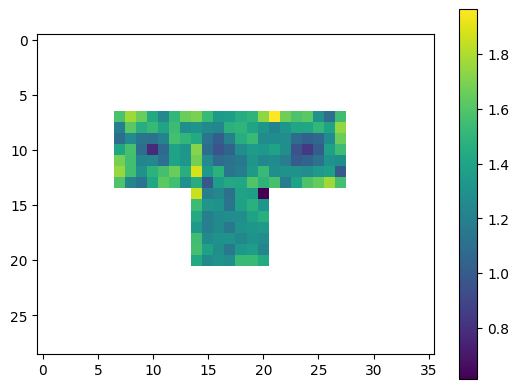

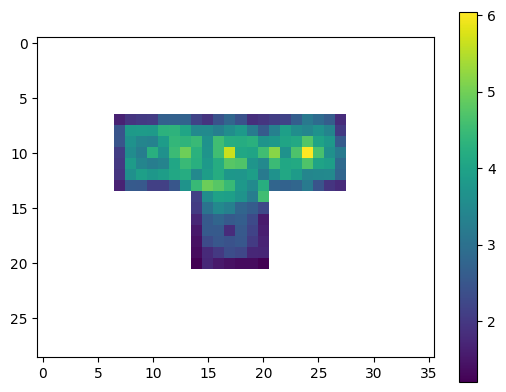

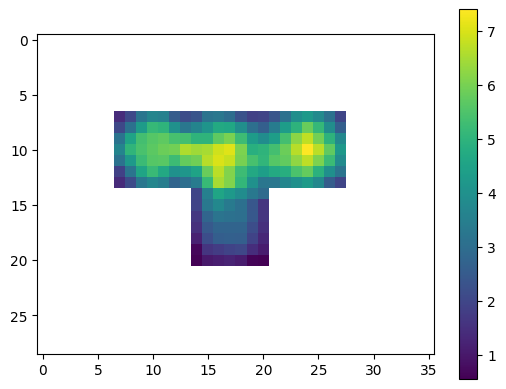

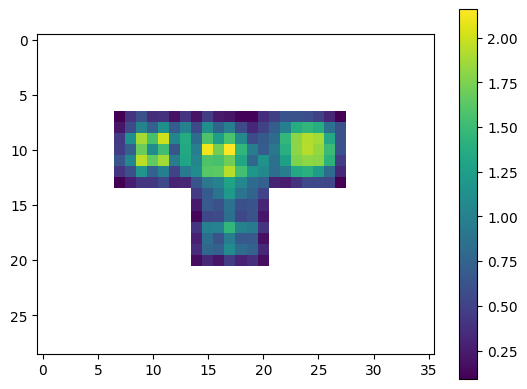

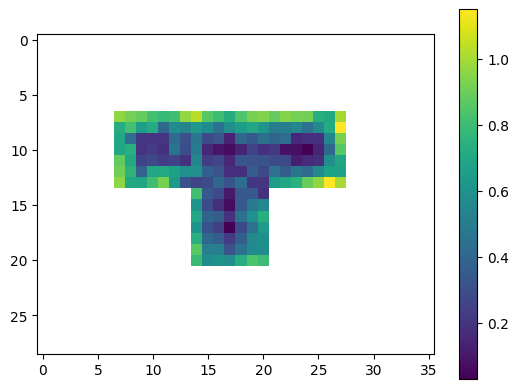

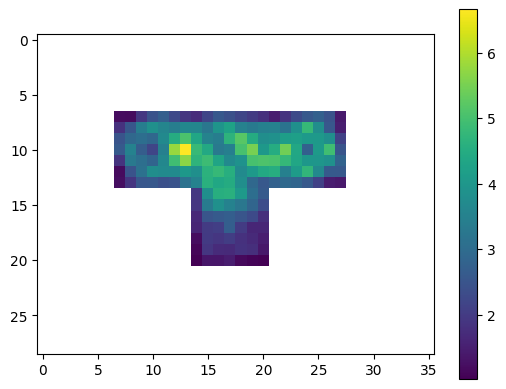

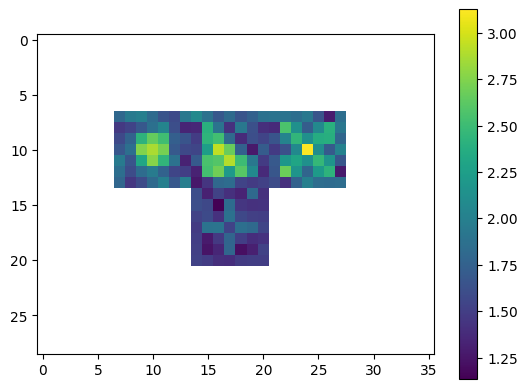

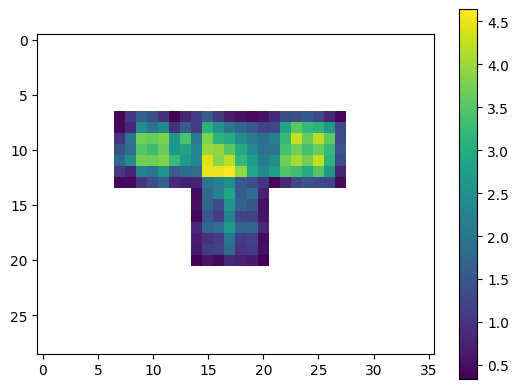

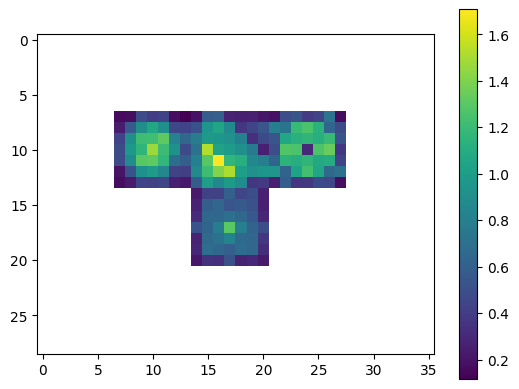

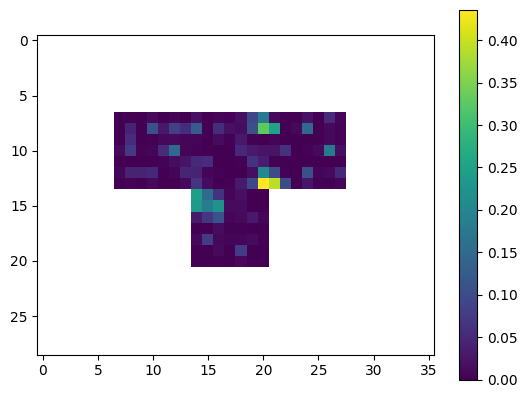

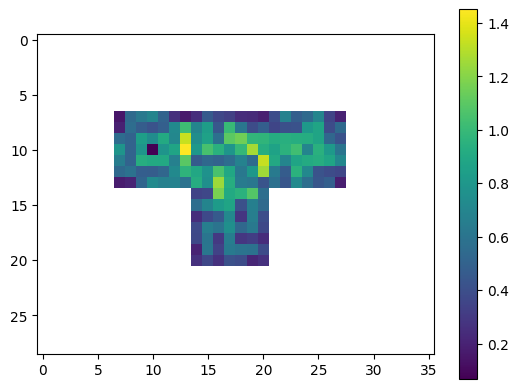

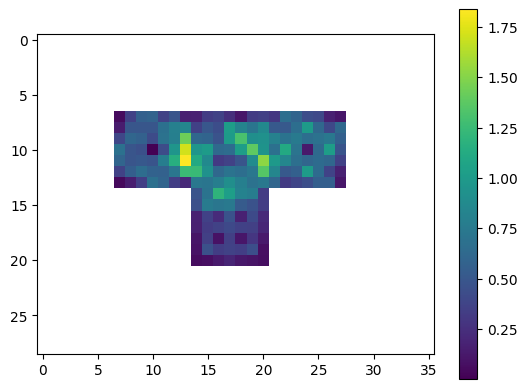

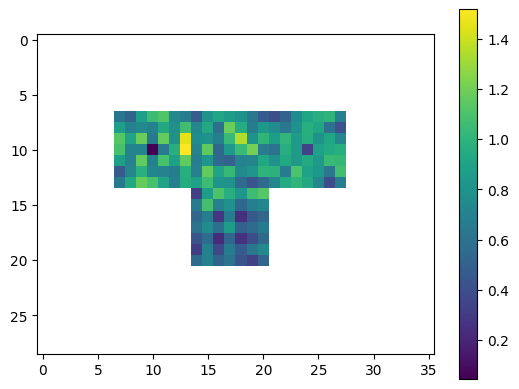

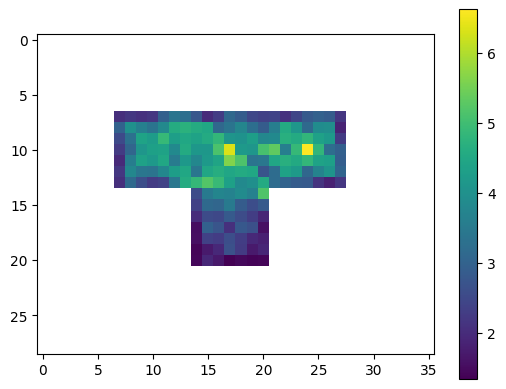

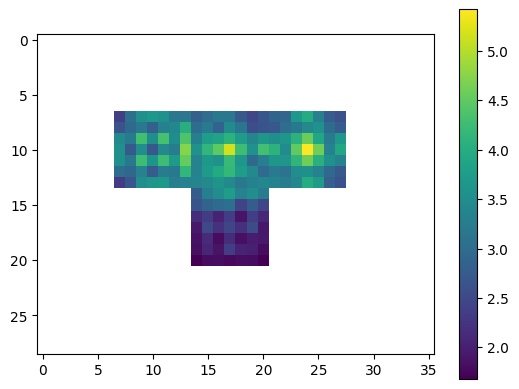

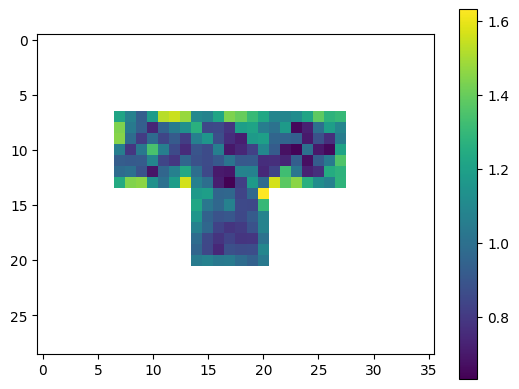

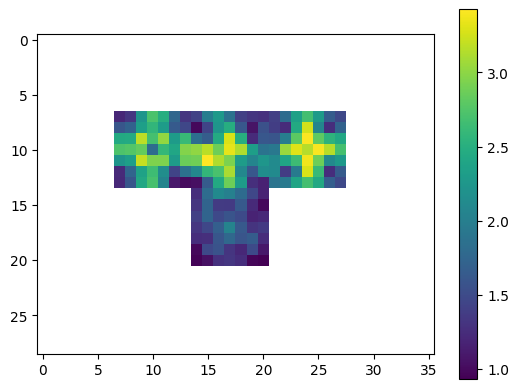

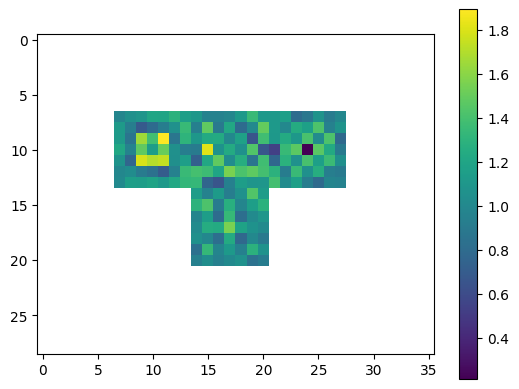

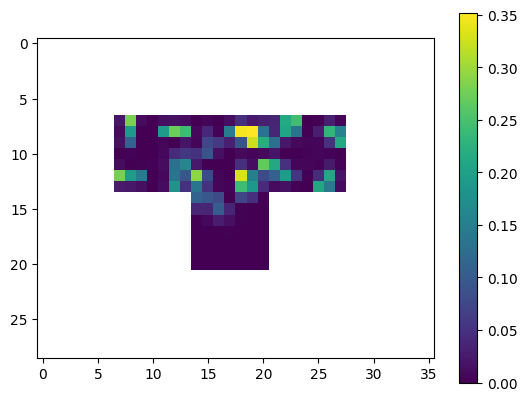

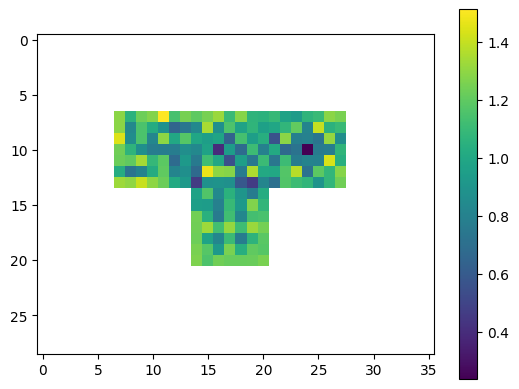

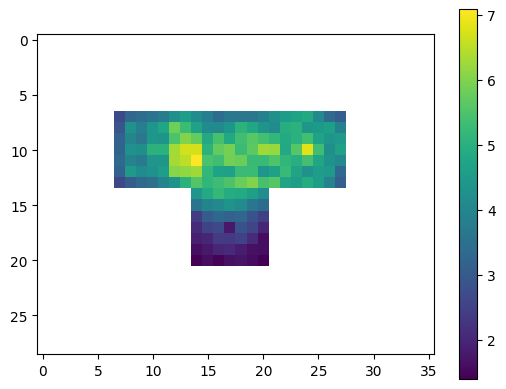

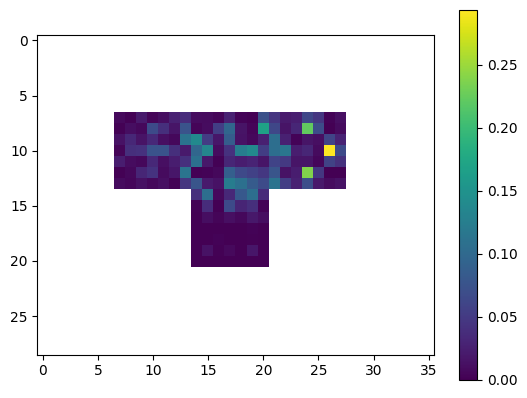

In [134]:

mean_hidden = []
positions = []
for position, neurons in position_hidden.items():
    avg_activation = torch.stack(neurons).mean(dim=0).detach().cpu().numpy()
    mean_hidden.append(avg_activation)
    positions.append(position)

mean_hidden = np.array(mean_hidden)
transposed_mean_hidden = mean_hidden.T

stuning_grid = np.full((64, HEIGHT, WIDTH), np.nan)

grid_count = 0
for neuron in transposed_mean_hidden:
    #print(type(neuron))
    #print(neuron)
    for xyindex in range(len(neuron)):
        xy = positions[xyindex]
        x = xy // 100
        y = xy % 100
        stuning_grid[grid_count, x, y] = neuron[xyindex]
    grid_count += 1

for i in range(64):

    plt.imshow(stuning_grid[i])
    plt.colorbar()
    plt.savefig(f"grid{i}.png")
    plt.show()

In [126]:
for i, agent in enumerate(stuning_agent_list):
    states = np.array(agent.states[1:])
    unique_xy = np.unique(states[:, :2], axis=0)
    print(i, len(unique_xy))

0 195
1 194
2 194
3 196
4 193
5 192
6 196
7 196
8 196
9 195
